<a href="https://colab.research.google.com/github/WVF-1/Introduction-to-Audio-Data/blob/main/NB1_Sensory_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎧 Audio Data Month — Project 1, Notebook 1
## Sensory Foundations: Learning to *See* Sound

> **Newsletter context:** Most people have only ever *listened* to audio data. This notebook teaches you to *look* at it — and in doing so, to understand the four fundamental representations that every audio analysis builds on.

**Dataset:** [UrbanSound8K](https://urbansounddataset.weebly.com/urbansound8k.html) — 8,732 labelled clips of urban sounds across 10 classes, sourced from real field recordings on Freesound.org. We work with **fold1** only (~874 clips, ~600 MB).

**What you will build by the end of this notebook:**
1. A waveform — amplitude over time
2. A spectrum — amplitude over frequency (via FFT)
3. A spectrogram — frequency over time, the core visual tool of audio analysis
4. A side-by-side class comparison: what does a *dog bark* look like versus a *gunshot*?

**Libraries:** `librosa`, `numpy`, `matplotlib`, `pandas`

---

## 0 · Setup

If you are running this on Google Colab, uncomment and run the install cell first.

In [8]:
# !pip install librosa --quiet

In [9]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# ── Palette ──────────────────────────────────────────────────────────────────
# A consistent cinema-adjacent palette used across the whole month.
# Deep charcoal background, warm amber and teal as the two main signal colours.
BG      = '#1a1a2e'   # deep navy-charcoal
PANEL   = '#16213e'   # slightly lighter panel
AMBER   = '#e8a838'   # warm signal colour (waveform, FFT)
TEAL    = '#2ec4b6'   # cool signal colour (spectrogram overlay, class 2)
CORAL   = '#e76f51'   # accent (annotations)
MUTED   = '#8d99ae'   # axis labels, secondary text
WHITE   = '#edf2f4'   # primary text

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   WHITE,
    'xtick.color':       MUTED,
    'ytick.color':       MUTED,
    'text.color':        WHITE,
    'grid.color':        '#2a2a4a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'figure.dpi':        120,
})

print('Setup complete.')

Setup complete.


In [10]:
# ── Path configuration ────────────────────────────────────────────────────────
# Point FOLD1_DIR at your local fold1 folder from the UrbanSound8K download.
# Expected structure:  UrbanSound8K/audio/fold1/

FOLD1_DIR = '/content/'   # ← adjust if needed
META_CSV  = 'UrbanSound8K/metadata/UrbanSound8k.csv'

CLASS_MAP = {
    0: 'air_conditioner',
    1: 'car_horn',
    2: 'children_playing',
    3: 'dog_bark',
    4: 'drilling',
    5: 'engine_idling',
    6: 'gun_shot',
    7: 'jackhammer',
    8: 'siren',
    9: 'street_music',
}

# Derive class from filename (format: [fsID]-[classID]-[occurrenceID]-[sliceID].wav)
def class_from_filename(path):
    name = os.path.basename(path)
    class_id = int(name.split('-')[1])
    return class_id, CLASS_MAP[class_id]

# Collect all WAV files in fold1
all_files = sorted(glob.glob(os.path.join(FOLD1_DIR, '*.wav')))
print(f'Found {len(all_files)} files in fold1.')

# Build a lightweight DataFrame for fold1
rows = []
for f in all_files:
    cid, cname = class_from_filename(f)
    rows.append({'path': f, 'class_id': cid, 'class_name': cname})
meta = pd.DataFrame(rows)

print('\nClass distribution in fold1:')
print(meta['class_name'].value_counts().to_string())

Found 862 files in fold1.

Class distribution in fold1:
class_name
jackhammer          120
children_playing    100
drilling            100
street_music        100
air_conditioner     100
dog_bark             97
engine_idling        88
siren                86
car_horn             36
gun_shot             35


---
## 1 · What is a WAV file?

Before we look at anything, it is worth pausing on what we are actually loading.

A `.wav` file is a sequence of **amplitude samples** — numbers between −1 and 1 — recorded at a fixed rate called the **sample rate** (measured in Hz, or samples per second). The UrbanSound8K files are all recorded at **44,100 Hz**, which means:

> For every second of audio, there are 44,100 numbers.

A 4-second clip is therefore an array of **176,400 numbers**. That is all a sound file is. Everything else — pitch, loudness, timbre — is encoded in the pattern of those numbers.

In [11]:
# Load one dog bark and one gunshot — our two contrasting examples throughout NB1
dog_path = meta[meta['class_name'] == 'dog_bark']['path'].iloc[0]
gun_path = meta[meta['class_name'] == 'gun_shot']['path'].iloc[0]

# sr=None preserves the original sample rate; mono=True mixes stereo down to one channel
y_dog, sr_dog = librosa.load(dog_path, sr=None, mono=True)
y_gun, sr_gun = librosa.load(gun_path, sr=None, mono=True)

print(f'Dog bark  | sample rate: {sr_dog:,} Hz | samples: {len(y_dog):,} | duration: {len(y_dog)/sr_dog:.2f}s')
print(f'Gun shot  | sample rate: {sr_gun:,} Hz | samples: {len(y_gun):,} | duration: {len(y_gun)/sr_gun:.2f}s')
print(f'\nFirst 10 raw sample values (dog bark):')
print(np.round(y_dog[:10], 5))

Dog bark  | sample rate: 48,000 Hz | samples: 192,000 | duration: 4.00s
Gun shot  | sample rate: 44,100 Hz | samples: 72,324 | duration: 1.64s

First 10 raw sample values (dog bark):
[0.33432 0.33112 0.3259  0.32175 0.31613 0.30551 0.29007 0.27017 0.24631
 0.22   ]


---
## 2 · The Waveform — Concept 1

The simplest way to visualise a sound: plot amplitude (y-axis) against time (x-axis).

The waveform tells you about **when** energy occurs and **how loud** it is, but nothing about pitch. A loud, low bass note and a loud, high whistle would look similar here — both are large excursions from zero.

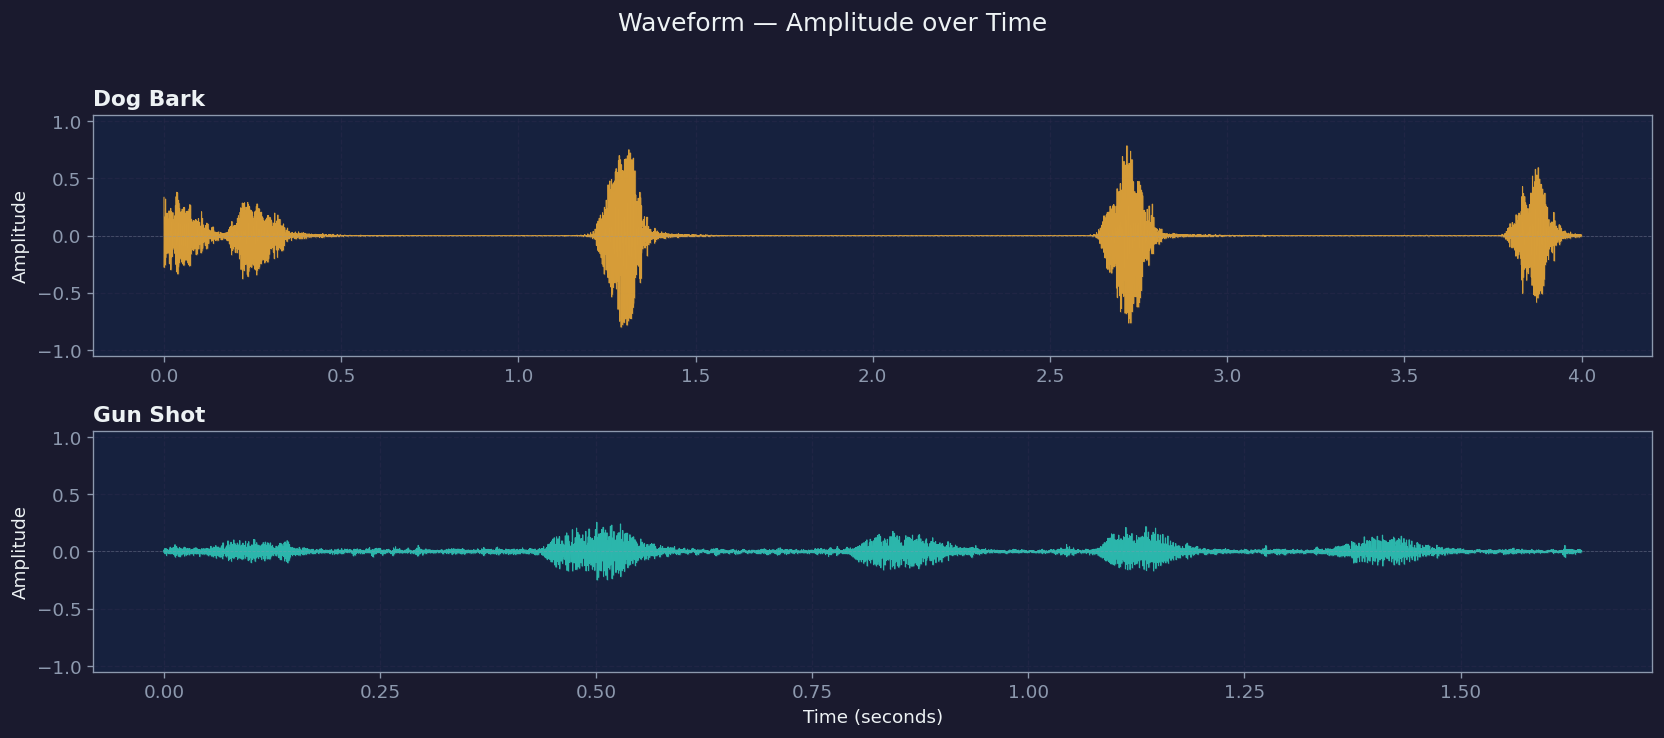


Notice:
  Dog bark  — multiple bursts of energy separated by silence (the bark, bark, bark rhythm)
  Gun shot  — a single sharp transient followed by a long decay (one event, then echo/room)


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
fig.suptitle('Waveform — Amplitude over Time', fontsize=15, y=1.02)

for ax, y, sr, label, colour in [
    (axes[0], y_dog, sr_dog, 'Dog Bark',  AMBER),
    (axes[1], y_gun, sr_gun, 'Gun Shot',  TEAL),
]:
    t = np.linspace(0, len(y) / sr, len(y))
    ax.plot(t, y, color=colour, linewidth=0.6, alpha=0.9)
    ax.axhline(0, color=MUTED, linewidth=0.5, linestyle='--', alpha=0.4)
    ax.set_ylabel('Amplitude', color=WHITE)
    ax.set_title(label, loc='left', pad=6)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True)
    ax.set_facecolor(PANEL)
    # Shade the envelope to make bursts of energy visible
    ax.fill_between(t, y, alpha=0.15, color=colour)

axes[1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.savefig('nb1_fig1_waveforms.png', bbox_inches='tight', facecolor=BG)
plt.show()

print('\nNotice:')
print('  Dog bark  — multiple bursts of energy separated by silence (the bark, bark, bark rhythm)')
print('  Gun shot  — a single sharp transient followed by a long decay (one event, then echo/room)')

---
## 2b · Sidebar — Loudness and Decibels

Looking at those waveforms, you might wonder: how do we measure *how loud* a sound is in a way that matches how we actually experience it?

**RMS amplitude** (Root Mean Square) gives us the average energy of a signal. But our ears are not linear — a sound twice as energetic does not feel twice as loud. The **decibel (dB)** scale accounts for this by being logarithmic:

> dB = 20 × log₁₀(RMS amplitude)

A difference of 10 dB corresponds roughly to a doubling of perceived loudness. The gun shot, despite being a brief click, should be significantly louder than the dog bark when measured this way.

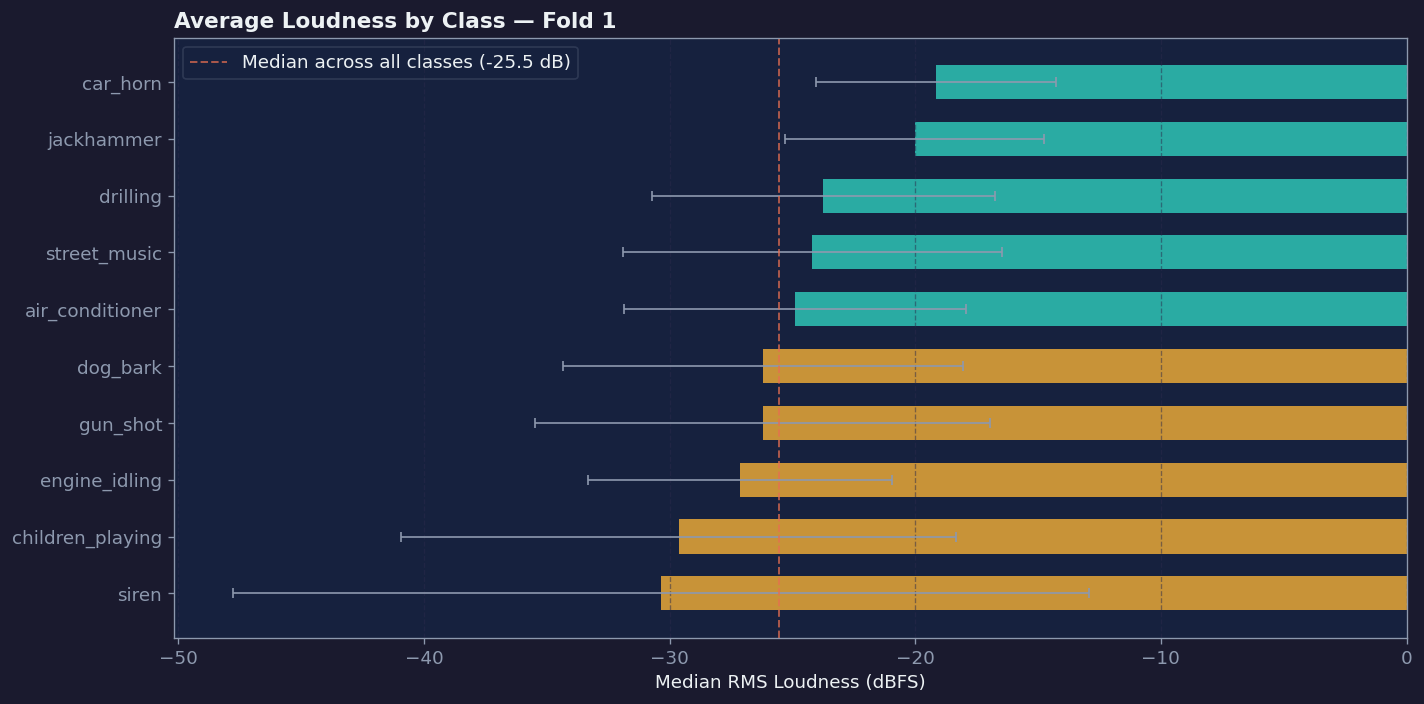

dBFS = decibels relative to full scale. 0 dBFS is the maximum possible amplitude.
More negative = quieter. Values here are typical for normalised audio clips.


In [13]:
# Compute RMS loudness in dB for every clip in fold1
rms_rows = []
for _, row in meta.iterrows():
    y, sr = librosa.load(row['path'], sr=22050, mono=True)
    rms = np.sqrt(np.mean(y**2))
    db  = 20 * np.log10(rms + 1e-9)   # +epsilon avoids log(0)
    rms_rows.append({'class_name': row['class_name'], 'rms_db': db})

rms_df = pd.DataFrame(rms_rows)
loudness = rms_df.groupby('class_name')['rms_db'].median().sort_values()
std      = rms_df.groupby('class_name')['rms_db'].std().reindex(loudness.index)

fig, ax = plt.subplots(figsize=(12, 6))
colours = [TEAL if v > loudness.median() else AMBER for v in loudness.values]
bars = ax.barh(loudness.index, loudness.values, xerr=std.values,
               color=colours, alpha=0.85, height=0.6,
               error_kw=dict(ecolor=MUTED, linewidth=1, capsize=3))
ax.axvline(loudness.median(), color=CORAL, linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Median across all classes ({loudness.median():.1f} dB)')
ax.set_xlabel('Median RMS Loudness (dBFS)', color=WHITE)
ax.set_title('Average Loudness by Class — Fold 1', loc='left')
ax.legend(framealpha=0.2, edgecolor=MUTED)
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('nb1_fig2_loudness.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('dBFS = decibels relative to full scale. 0 dBFS is the maximum possible amplitude.')
print('More negative = quieter. Values here are typical for normalised audio clips.')

---
## 3 · Sample Rate and the Nyquist Theorem — Concept 2

Why 44,100 Hz specifically? The answer comes from **Harry Nyquist**: to faithfully capture a frequency *f*, you must sample at least *2f* times per second — the **Nyquist rate**.

Human hearing tops out at roughly 20,000 Hz. So the minimum sample rate to capture everything we can hear is 2 × 20,000 = 40,000 Hz. The CD standard of 44,100 Hz adds a comfortable margin.

Below we visualise this directly: the same short segment of a dog bark resampled at three different rates.

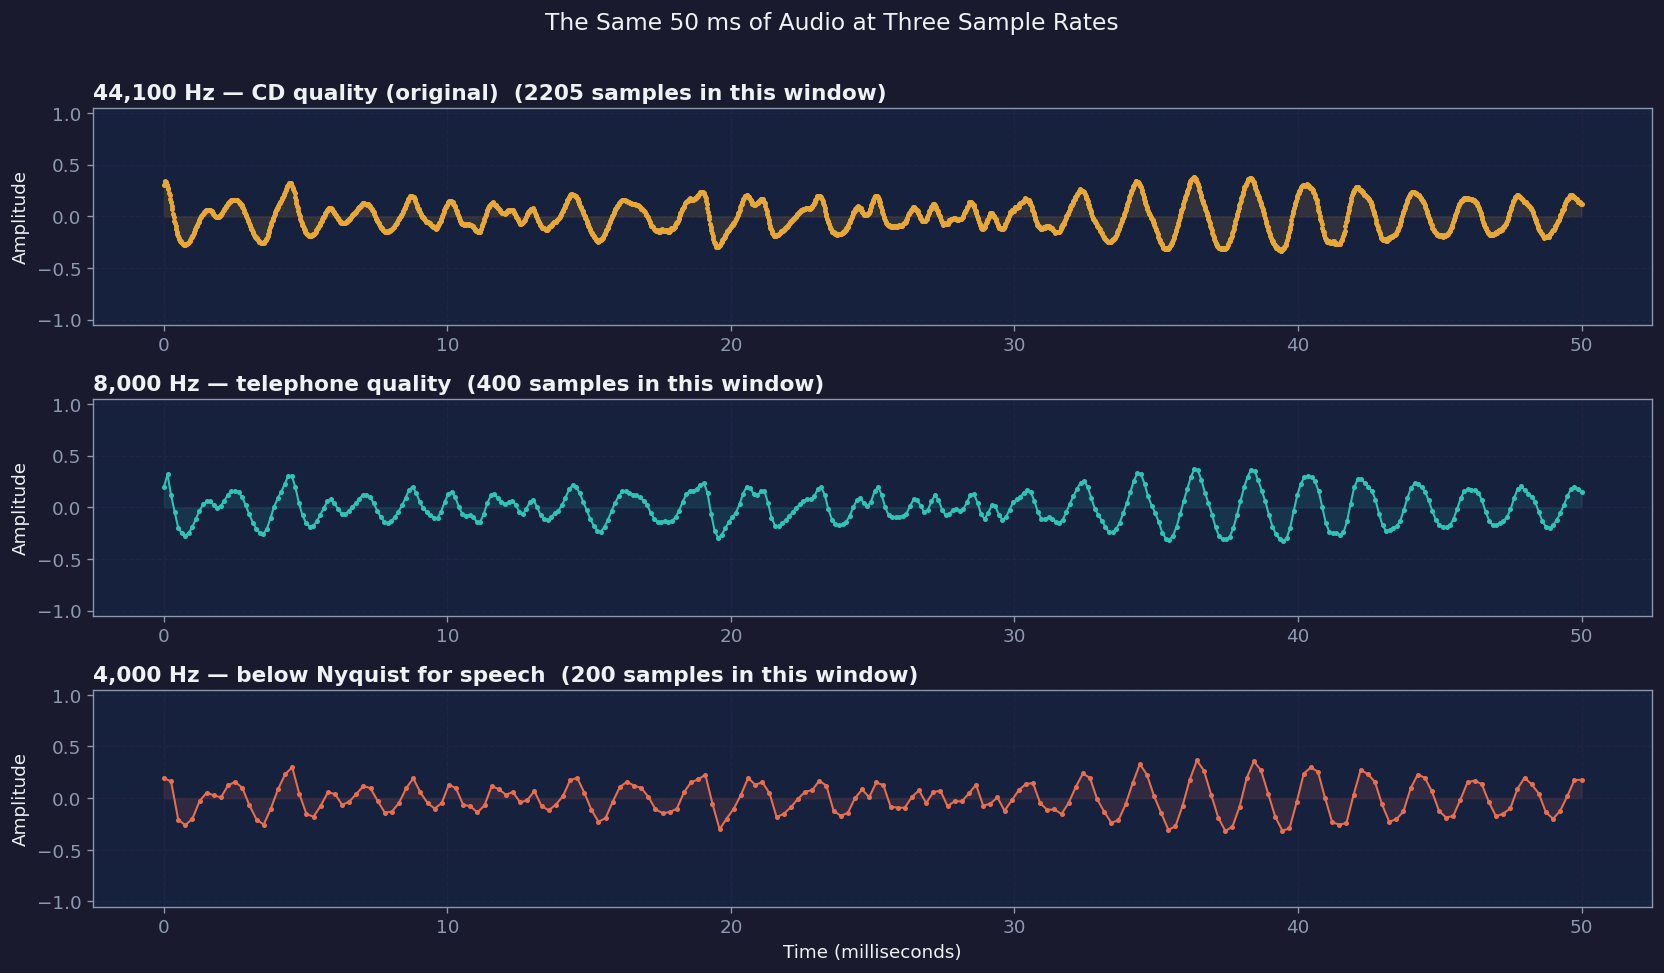

The dots on each line are the actual stored samples.
Fewer dots = less information = blockier reconstruction of the original waveform.


In [14]:
# Take a 0.05-second slice (50 ms) and show it at three sample rates
segment_sec = 0.05
sample_rates = [44100, 8000, 4000]
labels = ['44,100 Hz — CD quality (original)', '8,000 Hz — telephone quality', '4,000 Hz — below Nyquist for speech']
colours_sr = [AMBER, TEAL, CORAL]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
fig.suptitle('The Same 50 ms of Audio at Three Sample Rates', fontsize=14, y=1.01)

for ax, sr_target, label, col in zip(axes, sample_rates, labels, colours_sr):
    y_resampled, _ = librosa.load(dog_path, sr=sr_target, mono=True)
    n_samples = int(segment_sec * sr_target)
    seg = y_resampled[:n_samples]
    t   = np.linspace(0, segment_sec * 1000, n_samples)  # ms
    ax.plot(t, seg, color=col, linewidth=1.2, marker='o',
            markersize=max(2, 60 // n_samples), markerfacecolor=col)
    ax.fill_between(t, seg, alpha=0.12, color=col)
    ax.set_title(f'{label}  ({n_samples} samples in this window)', loc='left', pad=5)
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True)
    ax.set_facecolor(PANEL)

axes[-1].set_xlabel('Time (milliseconds)')
plt.tight_layout()
plt.savefig('nb1_fig3_sample_rates.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('The dots on each line are the actual stored samples.')
print('Fewer dots = less information = blockier reconstruction of the original waveform.')

---
## 4 · Frequency — Concept 3

The waveform shows *when* energy occurs. But a whistle and a bass rumble can have identical waveforms in terms of amplitude. The difference is **frequency** — how fast the wave oscillates.

The **Fast Fourier Transform (FFT)** decomposes a waveform into the frequencies that compose it. The result is a **spectrum** — a plot of *how much energy* exists at *each frequency*. This is the mathematical backbone of almost everything that follows in audio analysis.

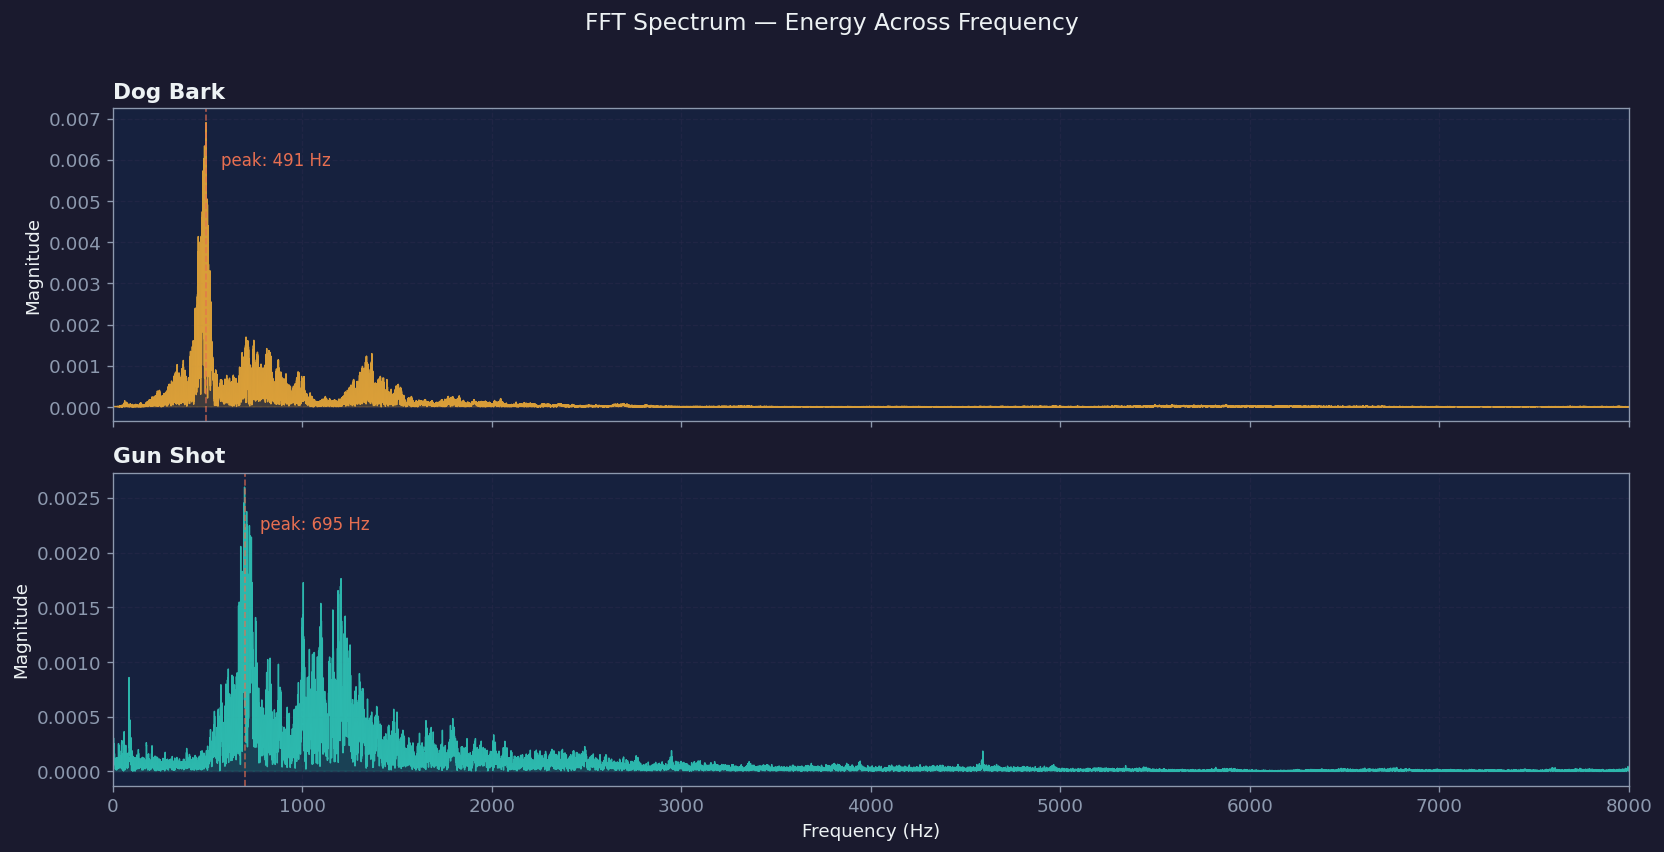

The dog bark concentrates energy in lower-mid frequencies (the body of the bark).
The gun shot spreads energy broadly — it is a broadband impulse noise.


In [15]:
# Resample to a standard rate for consistent analysis
SR = 22050
y_dog_r, _ = librosa.load(dog_path, sr=SR, mono=True)
y_gun_r, _ = librosa.load(gun_path, sr=SR, mono=True)

def compute_spectrum(y, sr):
    """Return (frequencies, magnitude) via FFT. Only positive frequencies."""
    N     = len(y)
    fft   = np.abs(np.fft.rfft(y)) / N      # normalise by clip length
    freqs = np.fft.rfftfreq(N, d=1.0 / sr)
    return freqs, fft

freqs_dog, mag_dog = compute_spectrum(y_dog_r, SR)
freqs_gun, mag_gun = compute_spectrum(y_gun_r, SR)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('FFT Spectrum — Energy Across Frequency', fontsize=14, y=1.01)

for ax, freqs, mag, label, colour in [
    (axes[0], freqs_dog, mag_dog, 'Dog Bark',  AMBER),
    (axes[1], freqs_gun, mag_gun, 'Gun Shot',  TEAL),
]:
    ax.plot(freqs, mag, color=colour, linewidth=0.8, alpha=0.9)
    ax.fill_between(freqs, mag, alpha=0.2, color=colour)
    ax.set_ylabel('Magnitude')
    ax.set_title(label, loc='left')
    ax.set_xlim(0, 8000)     # 0–8 kHz covers most perceptual content
    ax.set_facecolor(PANEL)
    ax.grid(True)
    # Annotate the peak
    peak_idx = np.argmax(mag)
    ax.axvline(freqs[peak_idx], color=CORAL, linewidth=1.0, linestyle='--', alpha=0.7)
    ax.text(freqs[peak_idx] + 80, mag[peak_idx] * 0.85,
            f'peak: {freqs[peak_idx]:.0f} Hz', color=CORAL, fontsize=10)

axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.savefig('nb1_fig4_spectrum.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('The dog bark concentrates energy in lower-mid frequencies (the body of the bark).')
print('The gun shot spreads energy broadly — it is a broadband impulse noise.')

---
## 5 · The Spectrogram — Concept 4

The FFT is powerful but it collapses time — it tells you *what* frequencies are present across the whole clip, but not *when*. A spectrogram solves this by computing the FFT repeatedly on short overlapping windows of the signal and stacking the results.

The result is a 2D image where:
- **x-axis** → time
- **y-axis** → frequency
- **colour** → energy (brighter = more energy)

This is the single most important visual tool in audio analysis. Once you can read a spectrogram, you can *see* what a sound is doing at every moment in time.

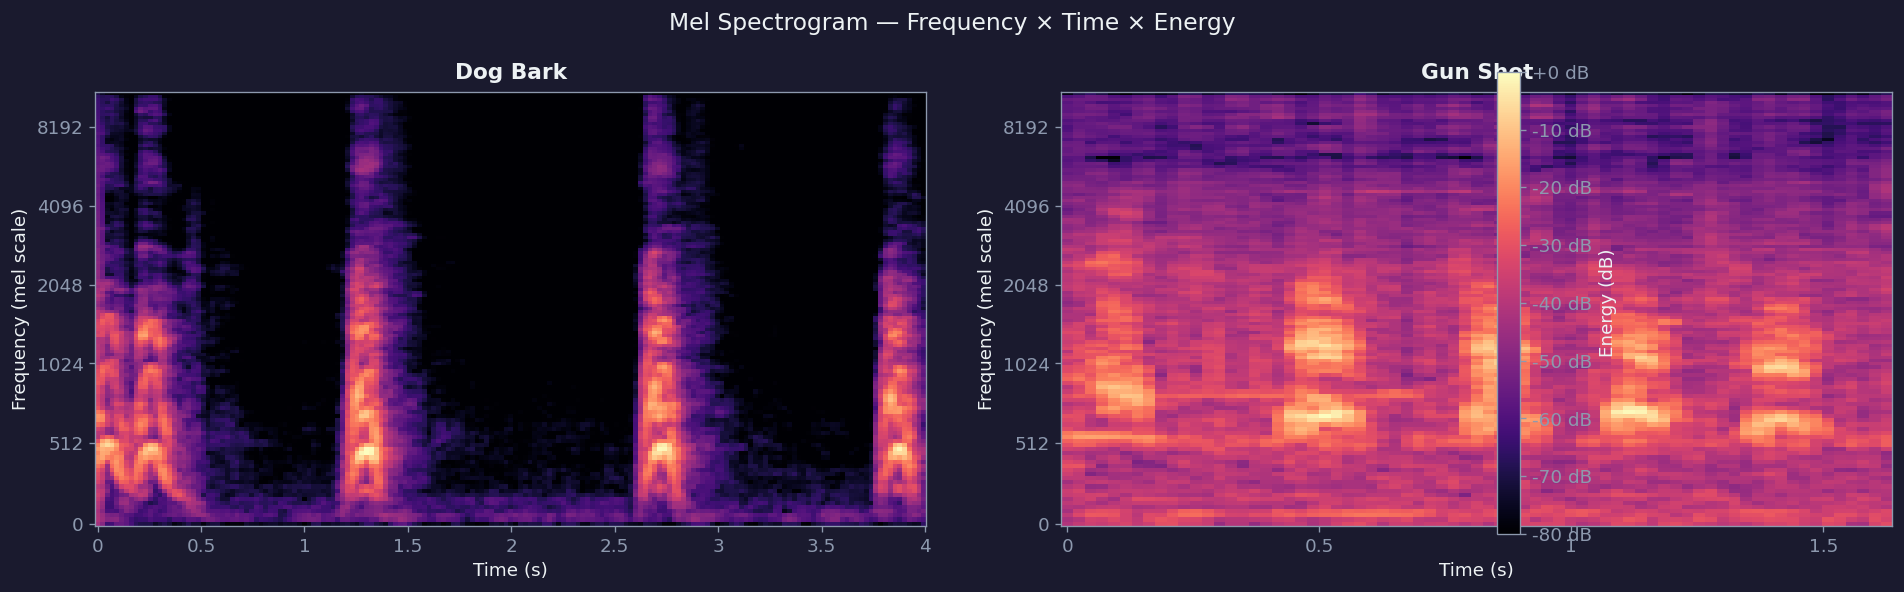

Dog bark:  horizontal bands of energy (the harmonic structure of a bark), repeating in time.
Gun shot:  a single vertical flash — broadband energy at one moment, then silence.


In [16]:
# Compute mel-spectrograms (mel scale = frequency axis warped to match human hearing)
# n_mels=128 gives a rich image; hop_length=512 controls time resolution

def mel_spectrogram(y, sr, n_mels=128, hop_length=512):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    S_db = librosa.power_to_db(S, ref=np.max)  # convert to dB scale
    return S_db

S_dog = mel_spectrogram(y_dog_r, SR)
S_gun = mel_spectrogram(y_gun_r, SR)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Mel Spectrogram — Frequency × Time × Energy', fontsize=14)

for ax, S, y_len, label in [
    (axes[0], S_dog, len(y_dog_r), 'Dog Bark'),
    (axes[1], S_gun, len(y_gun_r), 'Gun Shot'),
]:
    img = librosa.display.specshow(
        S, sr=SR, hop_length=512,
        x_axis='time', y_axis='mel',
        ax=ax, cmap='magma'
    )
    ax.set_title(label, pad=8)
    ax.set_ylabel('Frequency (mel scale)', color=WHITE)
    ax.set_xlabel('Time (s)', color=WHITE)
    ax.tick_params(colors=MUTED)
    ax.set_facecolor(PANEL)

fig.colorbar(img, ax=axes, format='%+2.0f dB', label='Energy (dB)')
plt.tight_layout()
plt.savefig('nb1_fig5_spectrograms.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('Dog bark:  horizontal bands of energy (the harmonic structure of a bark), repeating in time.')
print('Gun shot:  a single vertical flash — broadband energy at one moment, then silence.')

---
## 6 · Class Gallery — What Does Each Sound *Look* Like?

Now that we have the tools, let us look at all 10 classes. Each panel below shows one representative clip for a class — the same mel-spectrogram representation. The visual differences are striking even before any quantitative analysis.

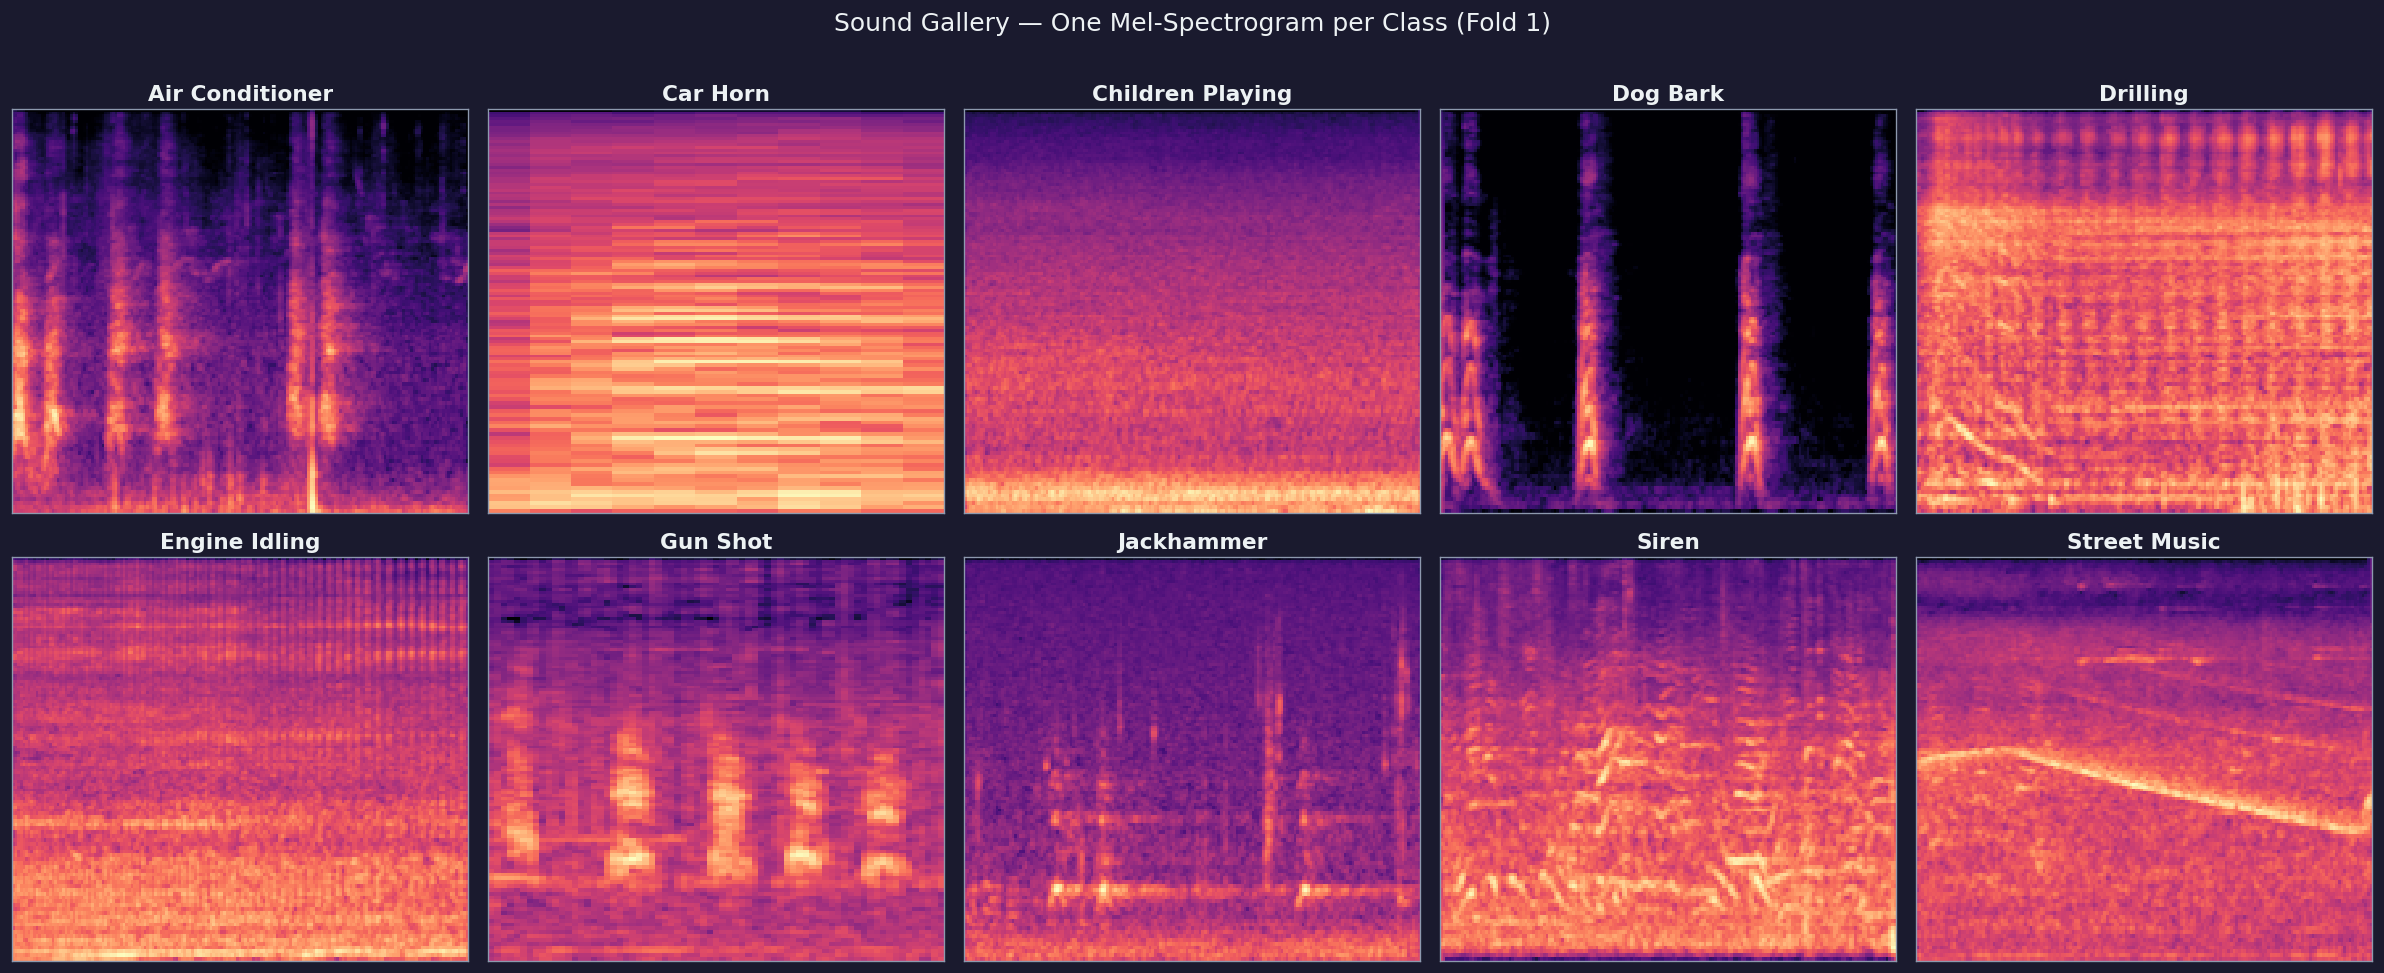

Notice the structural differences:
  Tonal/harmonic sounds (street music, siren) → horizontal banding
  Impulsive sounds (car horn, gun shot) → vertical flashes
  Broadband noise (drilling, jackhammer) → dense, filled images
  Rhythmic sounds (dog bark) → repeating patches


In [17]:
# Pick one representative clip per class (the first available in fold1)
representatives = {}
for cid, cname in CLASS_MAP.items():
    subset = meta[meta['class_id'] == cid]
    if not subset.empty:
        representatives[cname] = subset['path'].iloc[0]

n_classes = len(representatives)
ncols = 5
nrows = (n_classes + ncols - 1) // ncols   # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8 * nrows // 2))
axes_flat = axes.flatten()
fig.suptitle('Sound Gallery — One Mel-Spectrogram per Class (Fold 1)', fontsize=15, y=1.01)

for i, (cname, path) in enumerate(sorted(representatives.items())):
    ax = axes_flat[i]
    y, _ = librosa.load(path, sr=SR, mono=True)
    S    = mel_spectrogram(y, SR)
    librosa.display.specshow(S, sr=SR, hop_length=512,
                             x_axis='time', y_axis='mel',
                             ax=ax, cmap='magma')
    ax.set_title(cname.replace('_', ' ').title(), pad=5)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Hide any unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('nb1_fig6_gallery.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('Notice the structural differences:')
print('  Tonal/harmonic sounds (street music, siren) → horizontal banding')
print('  Impulsive sounds (car horn, gun shot) → vertical flashes')
print('  Broadband noise (drilling, jackhammer) → dense, filled images')
print('  Rhythmic sounds (dog bark) → repeating patches')

---
## 7 · Three Representations Side-by-Side — Putting It All Together

Finally, let us put all three representations on the same clip so that the relationship between them is explicit: waveform → spectrum → spectrogram are three different *views* of the same underlying signal.

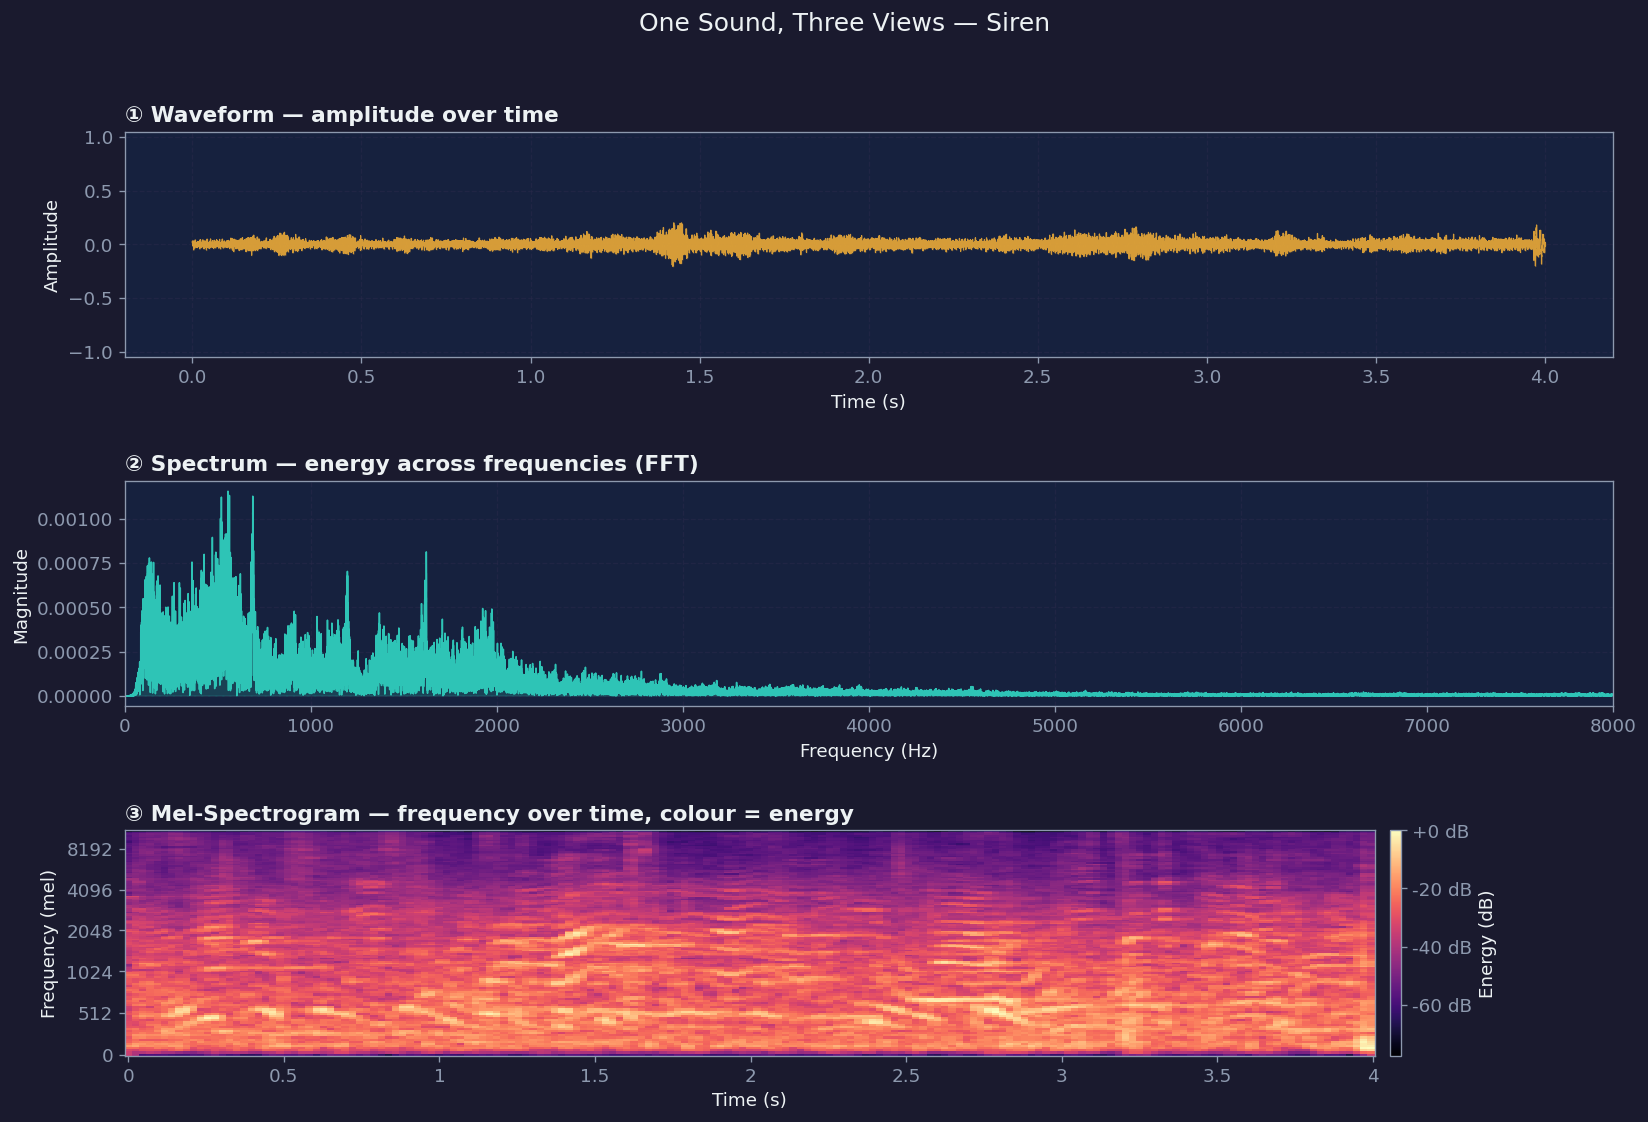

The sweeping pitch of the siren is invisible in the waveform,
partially visible as multiple peaks in the spectrum,
but unmistakable as a rising-and-falling band in the spectrogram.


In [18]:
# Choose one class for the integrated view — siren is dramatic and visually clear
siren_path = meta[meta['class_name'] == 'siren']['path'].iloc[0]
y_siren, _ = librosa.load(siren_path, sr=SR, mono=True)
S_siren    = mel_spectrogram(y_siren, SR)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('One Sound, Three Views — Siren', fontsize=15)

gs  = fig.add_gridspec(3, 1, hspace=0.55)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── Waveform ──
t = np.linspace(0, len(y_siren) / SR, len(y_siren))
ax1.plot(t, y_siren, color=AMBER, linewidth=0.7, alpha=0.9)
ax1.fill_between(t, y_siren, alpha=0.15, color=AMBER)
ax1.set_title('① Waveform — amplitude over time', loc='left')
ax1.set_ylabel('Amplitude')
ax1.set_xlabel('Time (s)')
ax1.set_ylim(-1.05, 1.05)
ax1.grid(True)
ax1.set_facecolor(PANEL)

# ── Spectrum (FFT averaged) ──
freqs_s, mag_s = compute_spectrum(y_siren, SR)
ax2.plot(freqs_s, mag_s, color=TEAL, linewidth=0.9)
ax2.fill_between(freqs_s, mag_s, alpha=0.2, color=TEAL)
ax2.set_xlim(0, 8000)
ax2.set_title('② Spectrum — energy across frequencies (FFT)', loc='left')
ax2.set_ylabel('Magnitude')
ax2.set_xlabel('Frequency (Hz)')
ax2.grid(True)
ax2.set_facecolor(PANEL)

# ── Mel-spectrogram ──
img = librosa.display.specshow(S_siren, sr=SR, hop_length=512,
                                x_axis='time', y_axis='mel',
                                ax=ax3, cmap='magma')
ax3.set_title('③ Mel-Spectrogram — frequency over time, colour = energy', loc='left')
ax3.set_ylabel('Frequency (mel)')
ax3.set_xlabel('Time (s)')
fig.colorbar(img, ax=ax3, format='%+2.0f dB', label='Energy (dB)', pad=0.01)

plt.savefig('nb1_fig7_three_views.png', bbox_inches='tight', facecolor=BG)
plt.show()
print('The sweeping pitch of the siren is invisible in the waveform,')
print('partially visible as multiple peaks in the spectrum,')
print('but unmistakable as a rising-and-falling band in the spectrogram.')

---
## 8 · Summary

You now have four tools for thinking about any audio file:

| Representation | What it shows | What it misses |
|---|---|---|
| **Waveform** | When energy occurs; overall dynamics | Which frequencies are present |
| **dB / RMS** | Perceived loudness, normalized for human hearing | Temporal structure, frequency content |
| **FFT Spectrum** | Which frequencies are present across the whole clip | When those frequencies occur |
| **Mel-Spectrogram** | Frequency over time, matched to human hearing | Fine timbral texture (→ that's Notebook 2) |

In **Notebook 2**, we extract MFCCs from every clip in fold1, build a feature matrix, and ask: can we *cluster* and *classify* sounds using only these compressed representations?

→ Continue to [Notebook 2: Feature Extraction & Pattern Discovery](NB2_Feature_Extraction.ipynb)